# 🏏 Cricket Partnership Network Analysis — Graph Algorithms

**Session 2 | Industrial Use Case 2 | DSA & ML for Business**

---

### Business Context
- Identify the most valuable **batting partnerships** in T20 cricket
- Traditional metrics focus on individuals — graph analysis reveals **collaborative value**
- Some players perform **40% better** with specific partners
- Data-driven partnership selection can be a competitive advantage in team building

### What You'll Learn
1. Build a **partnership graph** using NetworkX
2. Compute **degree centrality** and **betweenness centrality**
3. Identify the **strongest partnerships** by weighted composite score
4. Perform **community detection** to find natural batting groups
5. Visualize the network with force-directed layout

## Step 1: Import Libraries & Load Dataset

In [2]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import FancyBboxPatch

# Load dataset
df = pd.read_csv("../datasets/cricket_partnership_network.csv")
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nUnique players: {len(set(df['player_a']) | set(df['player_b']))}")
print(f"Total partnerships: {len(df)}")
df.head(10)

Dataset shape: (120, 6)
Columns: ['player_a', 'player_b', 'runs_together', 'matches_played', 'win_percentage', 'avg_partnership_sr']

Unique players: 25
Total partnerships: 120


,player_a,player_b,runs_together,matches_played,win_percentage,avg_partnership_sr
0,Virat Kohli,Shubman Gill,447,31,70.86,162.28
1,Virat Kohli,Suryakumar Yadav,944,42,74.34,172.06
2,Virat Kohli,Rishabh Pant,435,43,72.15,163.31
3,Virat Kohli,Faf du Plessis,1151,20,54.17,167.79
4,Virat Kohli,Glenn Maxwell,403,40,44.29,125.73
5,Virat Kohli,Nicholas Pooran,597,15,60.42,132.22
6,Virat Kohli,Andre Russell,484,32,34.69,159.22
7,Virat Kohli,Tilak Varma,671,39,45.47,110.95
8,Virat Kohli,Ishan Kishan,702,3,73.81,172.98
9,Rohit Sharma,KL Rahul,1166,44,34.05,134.62


## Step 2: Build Partnership Graph

Create a weighted undirected graph where:
- **Nodes** = Players
- **Edges** = Partnerships with composite weight = `runs_together × win_percentage / 100`

In [3]:
# Compute composite partnership weight
df['partnership_value'] = (df['runs_together'] * df['win_percentage'] / 100).round(2)

# Build graph
G = nx.Graph()

for _, row in df.iterrows():
    G.add_edge(row['player_a'], row['player_b'],
               weight=row['partnership_value'],
               runs=row['runs_together'],
               matches=row['matches_played'],
               win_pct=row['win_percentage'],
               strike_rate=row['avg_partnership_sr'])

print(f"Graph Summary:")
print(f"  Nodes (Players): {G.number_of_nodes()}")
print(f"  Edges (Partnerships): {G.number_of_edges()}")
print(f"  Density: {nx.density(G):.3f}")
print(f"  Is connected: {nx.is_connected(G)}")

Graph Summary:
  Nodes (Players): 25
  Edges (Partnerships): 120
  Density: 0.400
  Is connected: True


## Step 3: Centrality Analysis

- **Degree Centrality:** Who partners with the MOST players? (versatility)
- **Betweenness Centrality:** Who bridges different batting groups? (connector)
- **Weighted Degree (Strength):** Who accumulates the most partnership value?

In [4]:
# Compute centrality measures
degree_cent = nx.degree_centrality(G)
betweenness_cent = nx.betweenness_centrality(G, weight='weight')
closeness_cent = nx.closeness_centrality(G)

# Weighted degree (node strength)
strength = {node: sum(d['weight'] for _, _, d in G.edges(node, data=True)) for node in G.nodes()}

# Build player metrics DataFrame
players = pd.DataFrame({
    'player': list(G.nodes()),
    'degree_centrality': [degree_cent[n] for n in G.nodes()],
    'betweenness_centrality': [betweenness_cent[n] for n in G.nodes()],
    'closeness_centrality': [closeness_cent[n] for n in G.nodes()],
    'strength': [strength[n] for n in G.nodes()],
    'num_partners': [G.degree(n) for n in G.nodes()],
})

print("=== Top 10 by Degree Centrality (Most Versatile Partners) ===")
print(players.nlargest(10, 'degree_centrality')[['player', 'degree_centrality', 'num_partners']].to_string(index=False))

print("\n=== Top 10 by Betweenness Centrality (Bridge Players) ===")
print(players.nlargest(10, 'betweenness_centrality')[['player', 'betweenness_centrality']].to_string(index=False))

print("\n=== Top 10 by Partnership Strength (Total Value Generated) ===")
print(players.nlargest(10, 'strength')[['player', 'strength', 'num_partners']].to_string(index=False))

=== Top 10 by Degree Centrality (Most Versatile Partners) ===
         player  degree_centrality  num_partners
   Ishan Kishan           0.541667            13
Ruturaj Gaikwad           0.500000            12
   Shubman Gill           0.458333            11
  Hardik Pandya           0.458333            11
   Devon Conway           0.458333            11
    Rinku Singh           0.458333            11
   Rishabh Pant           0.416667            10
 Faf du Plessis           0.416667            10
Nicholas Pooran           0.416667            10
    Tilak Varma           0.416667            10

=== Top 10 by Betweenness Centrality (Bridge Players) ===
          player  betweenness_centrality
Yashasvi Jaiswal                0.184783
    Devon Conway                0.181159
 Quinton de Kock                0.177536
   Hardik Pandya                0.159420
 Ruturaj Gaikwad                0.126812
Suryakumar Yadav                0.108696
   Glenn Maxwell                0.108696
  AB de Vill

## Step 4: Top-10 Most Valuable Partnerships

=== Top 10 Most Valuable Partnerships ===

        player_a         player_b  runs  matches  win_pct  strike_rate  weight
   Andre Russell  Kane Williamson  1166        8    72.64       144.83  846.98
    David Warner     Devon Conway  1114        6    70.64       143.52  786.93
    Ishan Kishan  Ruturaj Gaikwad  1162       32    67.54       140.39  784.81
    Rohit Sharma     David Warner  1168       17    66.05       117.87  771.46
     Virat Kohli Suryakumar Yadav   944       42    74.34       172.06  701.77
Suryakumar Yadav     Rohit Sharma   939       20    70.64       158.94  663.31
    Ishan Kishan   AB de Villiers  1157       17    56.67       149.19  655.67
    Sanju Samson      Rinku Singh   959       41    67.97       158.36  651.83
 Ravindra Jadeja  Kane Williamson   965       24    66.40       161.22  640.76
     Virat Kohli   Faf du Plessis  1151       20    54.17       167.79  623.50


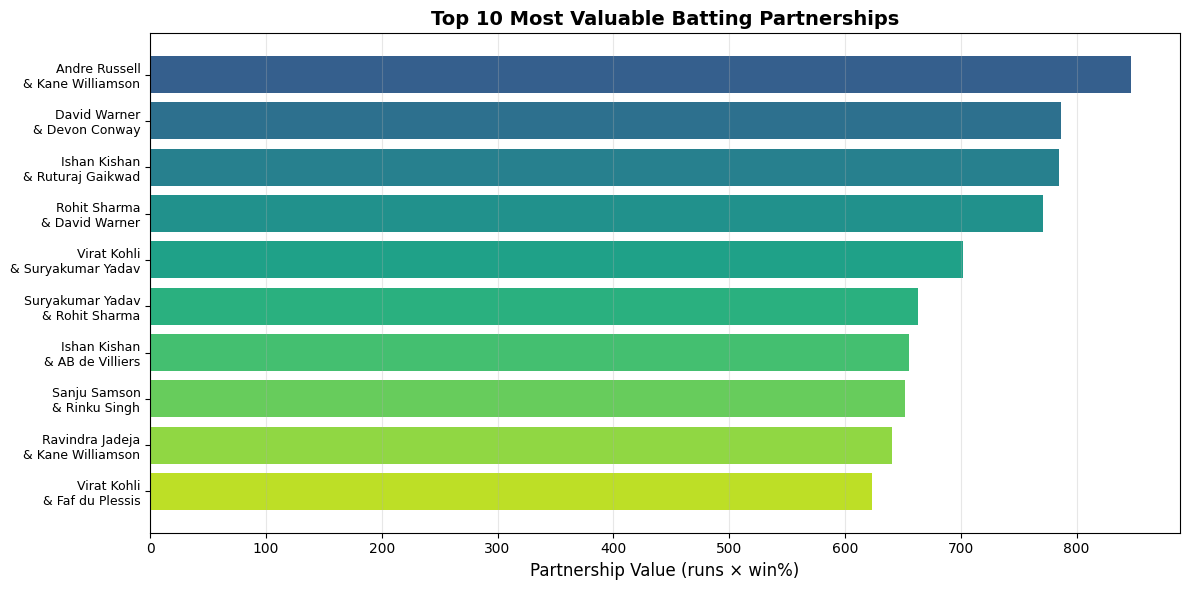

In [5]:
# Top partnerships by edge weight
edges_data = []
for u, v, d in G.edges(data=True):
    edges_data.append({'player_a': u, 'player_b': v, **d})

edges_df = pd.DataFrame(edges_data).sort_values('weight', ascending=False)

print("=== Top 10 Most Valuable Partnerships ===\n")
top_edges = edges_df.head(10)
print(top_edges[['player_a', 'player_b', 'runs', 'matches', 'win_pct', 'strike_rate', 'weight']].to_string(index=False))

# Visualization: top partnerships bar chart
fig, ax = plt.subplots(figsize=(12, 6))
labels = [f"{r['player_a']}\n& {r['player_b']}" for _, r in top_edges.iterrows()]
bars = ax.barh(range(len(top_edges)), top_edges['weight'].values,
               color=plt.cm.viridis(np.linspace(0.3, 0.9, len(top_edges))))
ax.set_yticks(range(len(top_edges)))
ax.set_yticklabels(labels, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Partnership Value (runs × win%)', fontsize=12)
ax.set_title('Top 10 Most Valuable Batting Partnerships', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Step 5: Network Visualization — Force-Directed Graph

Detected 3 communities:
  Community 1: Faf du Plessis, Ishan Kishan, Jos Buttler, Nicholas Pooran, Rishabh Pant, Ruturaj Gaikwad, Shubman Gill, Suryakumar Yadav, Tilak Varma, Virat Kohli
  Community 2: Andre Russell, Hardik Pandya, Kane Williamson, Ravindra Jadeja, Rinku Singh, Sanju Samson, Shreyas Iyer, Yashasvi Jaiswal
  Community 3: AB de Villiers, David Warner, Devon Conway, Glenn Maxwell, KL Rahul, Quinton de Kock, Rohit Sharma


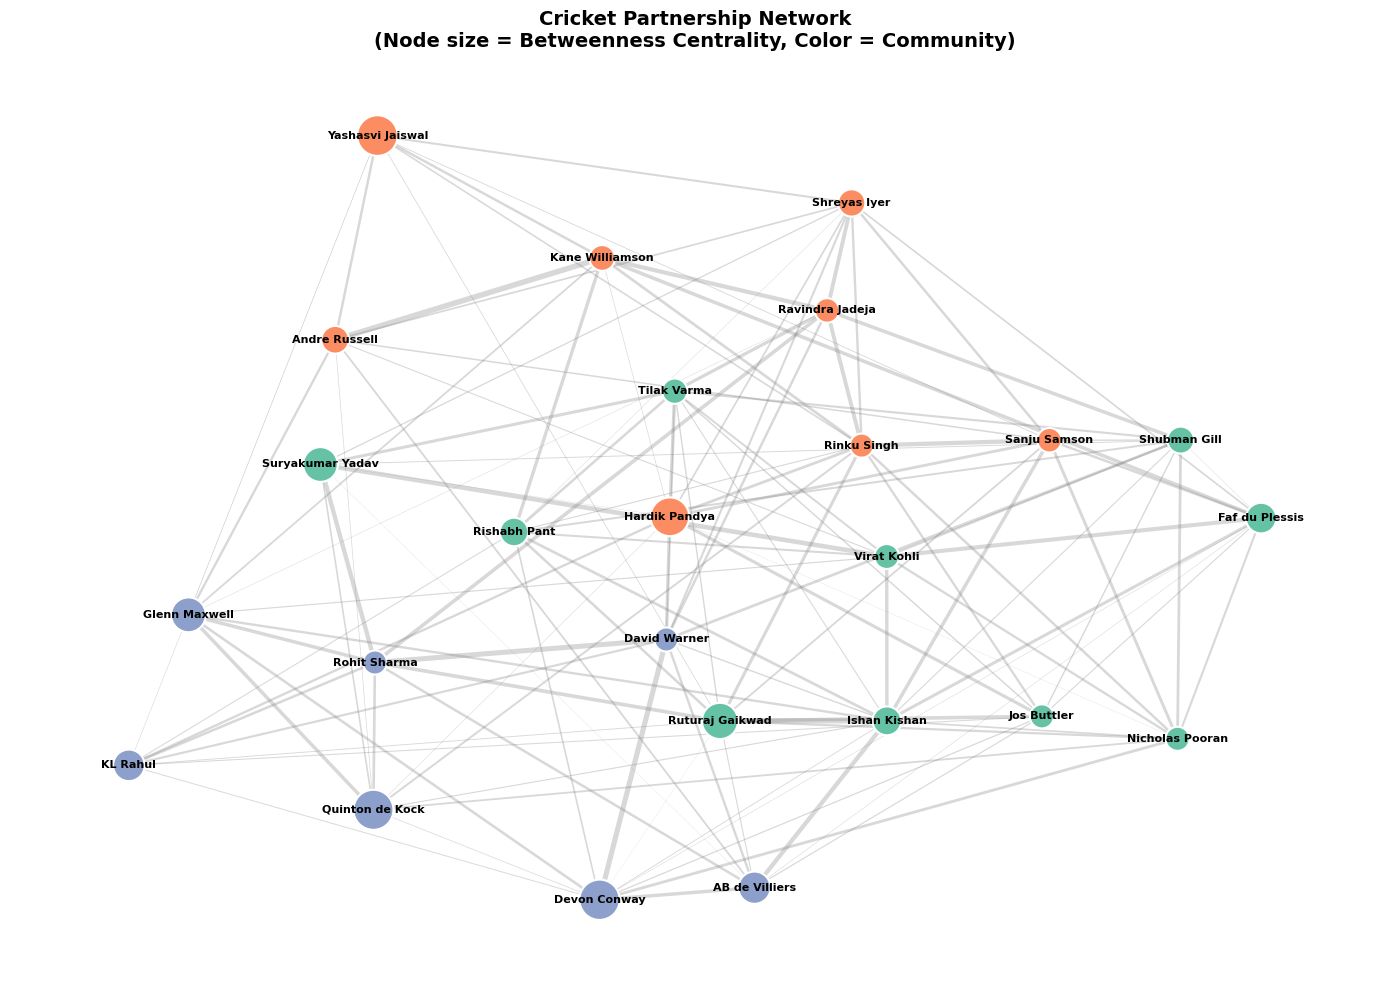

In [6]:
# Community detection using greedy modularity
from networkx.algorithms.community import greedy_modularity_communities

communities = list(greedy_modularity_communities(G, weight='weight'))
community_map = {}
for i, comm in enumerate(communities):
    for node in comm:
        community_map[node] = i

print(f"Detected {len(communities)} communities:")
for i, comm in enumerate(communities):
    print(f"  Community {i+1}: {', '.join(sorted(comm))}")

# Visualization
fig, ax = plt.subplots(figsize=(14, 10))
pos = nx.spring_layout(G, k=2, seed=42, weight='weight')

# Color by community
colors_map = plt.cm.Set2.colors
node_colors = [colors_map[community_map[n] % len(colors_map)] for n in G.nodes()]

# Node size by betweenness centrality
node_sizes = [300 + 3000 * betweenness_cent[n] for n in G.nodes()]

# Edge width by weight
edge_weights = [G[u][v]['weight'] / max(d['weight'] for _, _, d in G.edges(data=True)) * 4
                for u, v in G.edges()]

nx.draw_networkx_edges(G, pos, alpha=0.3, width=edge_weights, edge_color='gray', ax=ax)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes,
                       edgecolors='white', linewidths=1.5, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold', ax=ax)

ax.set_title('Cricket Partnership Network\n(Node size = Betweenness Centrality, Color = Community)',
             fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

## Step 6: Popularity vs Impact — Degree vs Weighted Betweenness

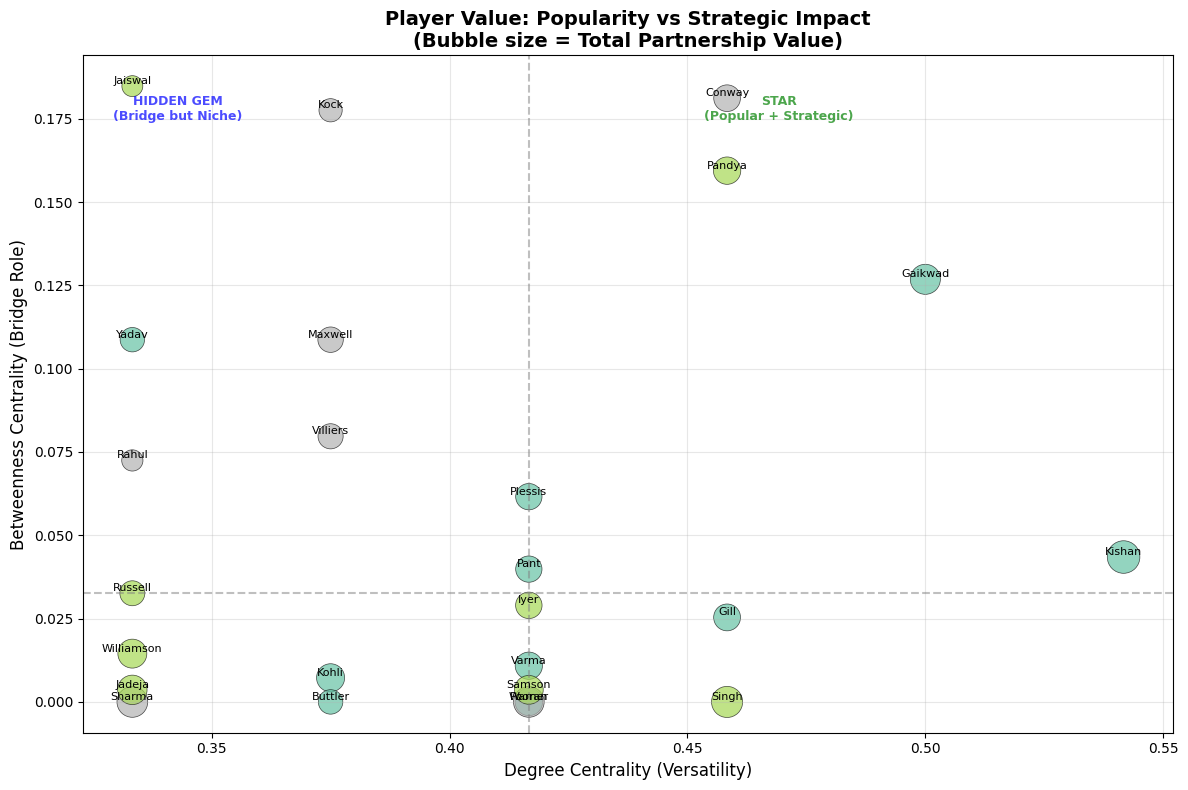

=== Hidden Value Players (High bridge value, fewer partners) ===
          player  degree_centrality  betweenness_centrality  strength
Yashasvi Jaiswal           0.333333                0.184783   1711.68
 Quinton de Kock           0.375000                0.177536   2230.64
    Devon Conway           0.458333                0.181159   3092.03
   Hardik Pandya           0.458333                0.159420   3287.74
Suryakumar Yadav           0.333333                0.108696   2511.38


In [7]:
# Scatter: Degree Centrality vs Betweenness Centrality
fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(players['degree_centrality'], players['betweenness_centrality'],
                     s=players['strength'] / players['strength'].max() * 500 + 50,
                     c=[community_map[p] for p in players['player']],
                     cmap='Set2', alpha=0.7, edgecolors='black', linewidths=0.5)

# Label all players
for _, row in players.iterrows():
    ax.annotate(row['player'].split()[-1], (row['degree_centrality'], row['betweenness_centrality']),
                fontsize=8, ha='center', va='bottom')

ax.set_xlabel('Degree Centrality (Versatility)', fontsize=12)
ax.set_ylabel('Betweenness Centrality (Bridge Role)', fontsize=12)
ax.set_title('Player Value: Popularity vs Strategic Impact\n(Bubble size = Total Partnership Value)',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Highlight quadrants
ax.axhline(y=players['betweenness_centrality'].median(), color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=players['degree_centrality'].median(), color='gray', linestyle='--', alpha=0.5)

# Quadrant labels
xlim = ax.get_xlim()
ylim = ax.get_ylim()
ax.text(xlim[1]*0.85, ylim[1]*0.9, 'STAR\n(Popular + Strategic)', ha='center', fontsize=9,
        color='green', fontweight='bold', alpha=0.7)
ax.text(xlim[0]+0.02, ylim[1]*0.9, 'HIDDEN GEM\n(Bridge but Niche)', ha='center', fontsize=9,
        color='blue', fontweight='bold', alpha=0.7)

plt.tight_layout()
plt.show()

# Identify "hidden value" players: high betweenness but low degree
players['hidden_value'] = players['betweenness_centrality'] / (players['degree_centrality'] + 0.01)
print("=== Hidden Value Players (High bridge value, fewer partners) ===")
print(players.nlargest(5, 'hidden_value')[['player', 'degree_centrality', 'betweenness_centrality', 'strength']].to_string(index=False))

## Step 7: Strategic Analysis & Recommendations

### Discussion Points:
1. **Batting Order Recommendation:** Use graph metrics (not just individual stats) to propose batting order
2. **Hidden Value Players:** Identify players with low individual fame but high partnership centrality
3. **Team Restructuring:** Which 2 new players would maximize overall network strength?
4. **Graph vs Traditional:** Compare graph-based selection with traditional selection methods
5. **Justify with metrics:** All recommendations backed by specific centrality values & visualizations

In [8]:
# === Strategic Analysis: Graph-Based Team Selection ===

print("=" * 70)
print("STRATEGIC RECOMMENDATION: Graph-Based Team Selection")
print("=" * 70)

# 1. Recommended batting order based on graph metrics
# Combine degree (versatility) + betweenness (strategic) + strength (proven value)
players['composite_graph_score'] = (
    0.3 * players['degree_centrality'] / players['degree_centrality'].max() +
    0.3 * players['betweenness_centrality'] / (players['betweenness_centrality'].max() + 0.001) +
    0.4 * players['strength'] / players['strength'].max()
)

print("\n1. RECOMMENDED BATTING ORDER (by Graph Composite Score):")
top_11 = players.nlargest(11, 'composite_graph_score')
for rank, (_, p) in enumerate(top_11.iterrows(), 1):
    print(f"   #{rank:2d}  {p['player']:<25s} | Graph Score: {p['composite_graph_score']:.3f} | "
          f"Partners: {p['num_partners']} | Strength: {p['strength']:.0f}")

# 2. Hidden value players
print("\n2. HIDDEN VALUE PLAYERS (High betweenness / low degree ratio):")
hidden = players.nlargest(3, 'hidden_value')
for _, p in hidden.iterrows():
    print(f"   {p['player']:<25s} | Betweenness: {p['betweenness_centrality']:.3f} | "
          f"Partners: {p['num_partners']} → Bridge between batting groups")

# 3. Network resilience
print("\n3. NETWORK RESILIENCE:")
top_betweenness = players.nlargest(1, 'betweenness_centrality').iloc[0]
print(f"   Most critical player: {top_betweenness['player']}")
print(f"   Betweenness centrality: {top_betweenness['betweenness_centrality']:.3f}")
# Simulate removal
G_removed = G.copy()
G_removed.remove_node(top_betweenness['player'])
components_after = nx.number_connected_components(G_removed)
print(f"   If removed: network splits into {components_after} component(s)")
print(f"   → Must have a backup partnership plan for this player's role")

STRATEGIC RECOMMENDATION: Graph-Based Team Selection

1. RECOMMENDED BATTING ORDER (by Graph Composite Score):
   # 1  Ruturaj Gaikwad           | Graph Score: 0.817 | Partners: 12 | Strength: 4060
   # 2  Devon Conway              | Graph Score: 0.801 | Partners: 11 | Strength: 3092
   # 3  Hardik Pandya             | Graph Score: 0.783 | Partners: 11 | Strength: 3288
   # 4  Ishan Kishan              | Graph Score: 0.770 | Partners: 13 | Strength: 4848
   # 5  Quinton de Kock           | Graph Score: 0.678 | Partners: 9 | Strength: 2231
   # 6  Yashasvi Jaiswal          | Graph Score: 0.624 | Partners: 8 | Strength: 1712
   # 7  Rinku Singh               | Graph Score: 0.616 | Partners: 11 | Strength: 4385
   # 8  Glenn Maxwell             | Graph Score: 0.612 | Partners: 9 | Strength: 2771
   # 9  David Warner              | Graph Score: 0.581 | Partners: 10 | Strength: 4249
   #10  Faf du Plessis            | Graph Score: 0.578 | Partners: 10 | Strength: 2999
   #11  Suryakumar Yad